In [20]:
## modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('./data/processed_FULL.csv', parse_dates = ['UTC Date/Time'], index_col=0)

In [16]:
## combine csvs into one big ol csv

oct_data = pd.read_csv('./data/october_RAW.csv', parse_dates = ['UTC Date/Time'])
nov_data = pd.read_csv('./data/november_RAW.csv', parse_dates = ['UTC Date/Time'])

full_data = pd.concat([oct_data, nov_data])

full_data = full_data[['UTC Date/Time', 'CO2 (ppm) raw']] # select useful cols
full_data['UTC Date/Time'] = full_data['UTC Date/Time'].dt.tz_localize(None) # un-localise timezone
full_data['UTC Date/Time'] = full_data['UTC Date/Time'].dt.round(freq='min')

full_data.to_csv('./data/processed_FULL.csv')

In [24]:
daytime = ('00:00', '20:00')

isabel_timestamps = [
    '10-27', '10-28', '11-17'
]

isabel_decays = [(8.8, 14.0), (8.8, 11.8), (8.9, 14.0)]

pablo_timestamps = [
    '10-29', '10-30', '11-18'
]

pablo_decays = [(10.4, 13.4), (10.3, 13.6), (9.8, 14)]
# (6.6, 9.1); 
# 9.33 - 10.1; 10.3 - 13.6
# (6.4, 9.1); 9.8 - 14

rishi_timestamps = [
    '11-05', '11-06', '11-21'
]

rishi_decays = [(8.5, 23.1), (8.75, 12), (8, 14)]
# 10.4 - 23.1
# 8.75 - 15
# 9.4 - 14

johanna_timestamps = [
    '11-12', '11-13', '10-24'
]

johanna_decays = [(9.5, 15), (10.4, 14), (1, 2)]
# 9.5 - 15
# 10.4 - 15
# NONE

timestamps_ALL = np.stack([
    rishi_timestamps,
    isabel_timestamps,
    johanna_timestamps,
    pablo_timestamps
])

decays_ALL = np.stack([
    rishi_decays,
    isabel_decays,
    johanna_decays,
    pablo_decays
])

names = [
    'A: 1800', 'B: 1896', 'C: 2007', 'D: 2019'
]

colors = [
    "#4E008A", "#FF33E4", "#F14646", "#FFAB0E"
][::-1]

scenarios = [
    'A', 'B', 'C'
]

ages = 2025 - np.array([
    1800, 1896, 2007, 2019
])

In [21]:
from datetime import datetime, timedelta
from dateutils import relativedelta
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates

cmap = mpl.colormaps['tab20b']

def zero_data(df):

    new_df = df.copy()
    # minutes = new_df['UTC Date/Time'].dt.minutes
    # hours = new_df['UTC Date/Time'].dt.hours
    # new_df['Time since Midnight'] = minutes + hours

    dates = new_df['UTC Date/Time']
    new_df['Time since Midnight'] = (dates - dates.min()).astype('timedelta64[s]').astype(int) / 3600

    return new_df.sort_values(by='Time since Midnight')

def get_data_period(df, ts_date, hrs=20):

    date = datetime.strptime(ts_date, r'%m-%d') + relativedelta(year=2025)

    new_data = df[(df['UTC Date/Time'] > date) & (df['UTC Date/Time'] < date + relativedelta(hours = hrs))]

    return zero_data(new_data)


C:\Users\nookh\AppData\Local\Temp\ipykernel_25276\1273193366.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  decay_data['translated'] = decay_data['CO2 (ppm) raw'] - decay_min
C:\Users\nookh\AppData\Local\Temp\ipykernel_25276\1273193366.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  decay_data['translated'] = decay_data['CO2 (ppm) raw'] - decay_min
C:\Users\nookh\AppData\Local\Temp\ipykernel_25276\1273193366.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

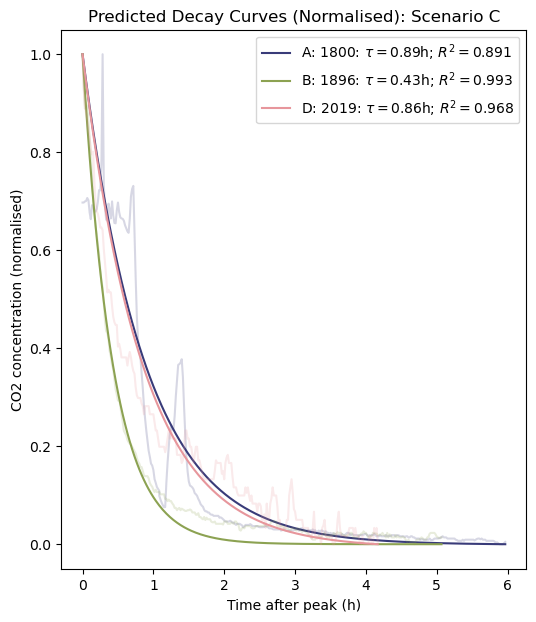

In [33]:
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

def exp_decay(x, a, b):
    return a*np.exp(- b*x)

def reverse_index(df):
    return df.reindex(index=df.index[::-1]).reset_index()

def scale(ser):
    return (ser - ser.min()) / (ser.max() - ser.min())

fig, ax = plt.subplots(1, 1, figsize=(6, 7))

person = 0
scenario = 2

tau = []

for person in [0, 1, 3]: #[0, 1, 3]:#range(4):
    run_data = get_data_period(data, timestamps_ALL[person][scenario])
    run_data['ts'] = run_data['Time since Midnight']

    times = decays_ALL[person][scenario]
    decay_data = run_data[(run_data['ts'] > times[0]) & (run_data['ts'] < times[1])]

    decay_min = decay_data['CO2 (ppm) raw'][-20:].mean()
    decay_data['translated'] = decay_data['CO2 (ppm) raw'] - decay_min

    curve = curve_fit(exp_decay, decay_data['ts'] - decay_data['ts'].min(), decay_data['translated'])
    
    a, b = curve[0]
    pcov = curve[1]

    tau.append(1/b)

    #display(f'{a} {b}')

    errors = np.sqrt(np.diag(pcov))

    x = decay_data['ts']
    scaled_x = x - x.min()

    y = decay_data['CO2 (ppm) raw']
    scaled_y = scale(y)

    pred_y = exp_decay(scaled_x, a, b) + decay_min
    scaled_pred_y = scale(pred_y)

    zeros = scaled_y < 0.1
    r2 = r2_score(y, pred_y)
    r2_no_zero = r2_score(y[~zeros], pred_y[~zeros])

    #display(f'{person}: {r2} // {r2_no_zero}')

    ax.plot(scaled_x, scaled_y, color=cmap(person/4), alpha=0.2)
    ax.plot(scaled_x, scaled_pred_y, color=cmap(person/4), label=f'{names[person]}: $\\tau={1/b:.02f}$h; $R^2={r2:.03f}$') # ; error: {100*errors[1]/b:.02f}%

ax.set_title(f'Predicted Decay Curves (Normalised): Scenario {scenarios[scenario]}')
ax.set_xlabel('Time after peak (h)')
ax.set_ylabel('CO2 concentration (normalised)')
#ax.set_xlim(0, 1)
#ax.set_ylim(0, 1)
ax.legend()

ax.set_yscale('linear')

In [43]:
from scipy.stats import pearsonr

ssconc = [
    445, 430, 430
]

pearsonr(ages[[0, 1, 2]], ssconc)

PearsonRResult(statistic=np.float64(0.8443682762006561), pvalue=np.float64(0.3599520561921625))

Text(0, 0.5, 'CO2 Concentration (ppm)')

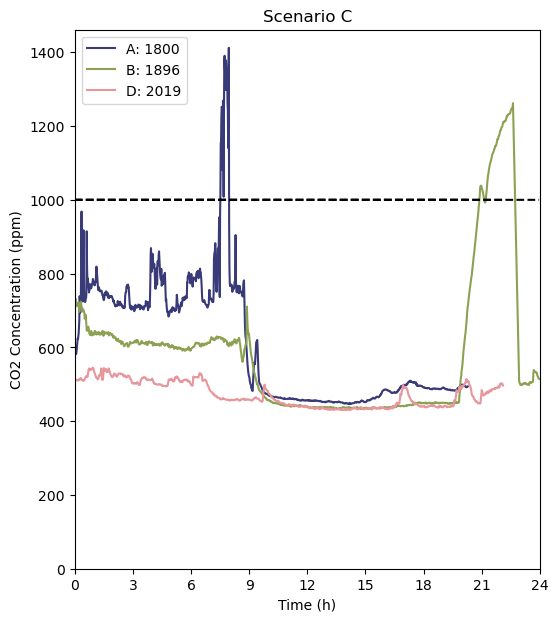

In [7]:
from matplotlib.ticker import MaxNLocator
from joblib import load

def prep_sklearn_data(ser):
    '''
    pass series, outputs a numpy array with no NaN values
    '''

    out = ser.to_numpy()
    
    nan_vals = np.isnan(out)

    return (out[~nan_vals].reshape(-1, 1), nan_vals)

cal_model = load('calibration_model.joblib')

scenario = 2

fig, ax = plt.subplots(figsize=(6, 7))

ax.set_title(f'Scenario {scenarios[scenario]}')

max_hrs = 24

for i in [0, 1, 3]:#range(4):

    ts = timestamps_ALL[i, scenario]

    plot_data = get_data_period(data, ts, hrs=max_hrs)
    nanless_data, nans = prep_sklearn_data(plot_data['CO2 (ppm) raw'])

    calibrated_data = cal_model.predict(nanless_data)
    time_pts = plot_data['Time since Midnight'][~nans]

    ax.plot(time_pts, calibrated_data, label=names[i], color=cmap(i/4))
    ## plot recommended amount of CO2
    rec_data = [1000 for _ in plot_data['Time since Midnight']]
    
    ax.plot(plot_data['Time since Midnight'], rec_data, '--k')

ax.set_ylim(0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlim(0, max_hrs)
ax.legend()

ax.set_xlabel('Time (h)')
ax.set_ylabel('CO2 Concentration (ppm)')

In [8]:
start = 2
end = 6

person = 0
scenario = 2

ts = timestamps_ALL[person, scenario]
plot_data = get_data_period(data, ts, hrs=24)

rel_data, nans = prep_sklearn_data(plot_data[(plot_data['Time since Midnight'] > start) & (plot_data['Time since Midnight'] < end)]['CO2 (ppm) raw'])
cal_model.predict(rel_data).min()

np.float64(683.6154347765593)

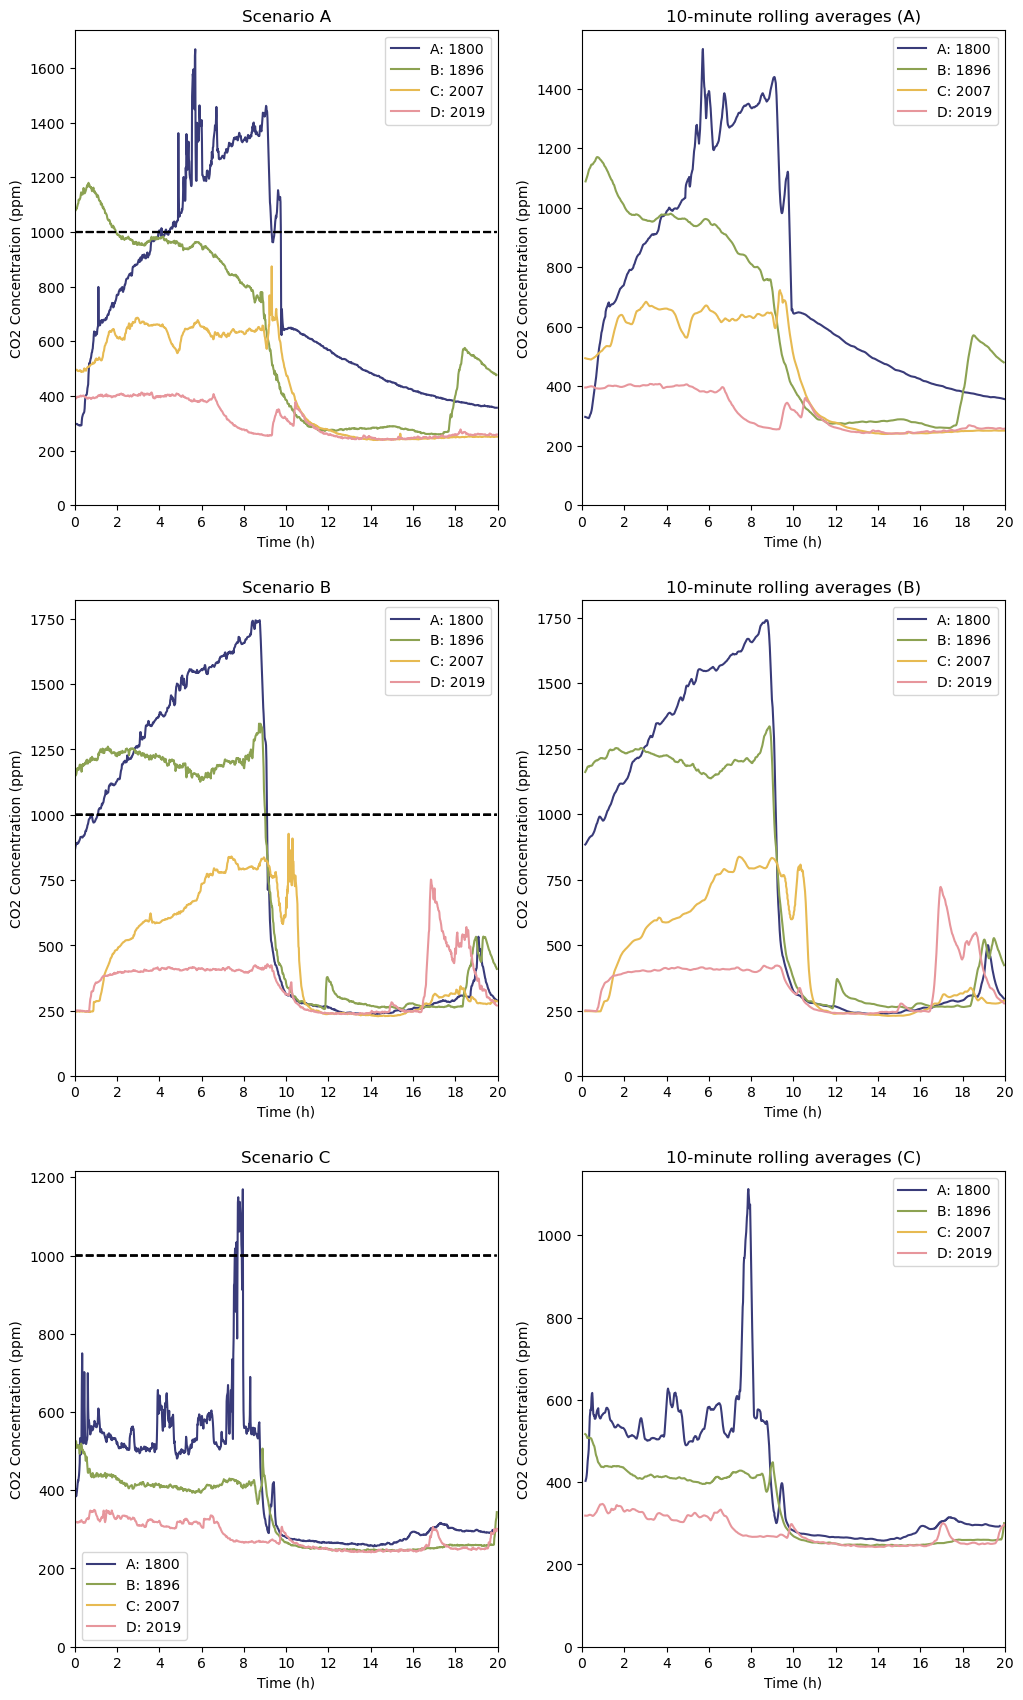

In [9]:
from matplotlib.ticker import MaxNLocator

fig, axs = plt.subplots(3, 2, figsize=(12, 21))

for j in range(3):

    ax = axs[j]
    ax[0].set_title(f'Scenario {scenarios[j]}')
    ax[1].set_title(f'10-minute rolling averages ({scenarios[j]})')

    for i in range(4):

        ts = timestamps_ALL[i, j]

        plot_data = get_data_period(data, ts)

        ax[0].plot(plot_data['Time since Midnight'], plot_data['CO2 (ppm) raw'], label=names[i], color=cmap(i/4))
        ax[1].plot(plot_data['Time since Midnight'], plot_data['CO2 (ppm) raw'].rolling(window=10).mean(), label=names[i], color=cmap(i/4))

        ## plot recommended amount of CO2
        rec_data = [1000 for _ in plot_data['Time since Midnight']]
        
        ax[0].plot(plot_data['Time since Midnight'], rec_data, '--k')

        #plot_data.plot(x = 'Time since Midnight', y='CO2 (ppm) raw', ax=ax, label = names[i], color=cmap((i)/4), x_compat=True)
        #plot_data.set_index('UTC Date/Time').groupby(plot_data.index.hour)['CO2 (ppm) raw'].plot(kind='line', ax=ax)

    #locator = mdates.AutoDateLocator()
    #formatter = mdates.ConciseDateFormatter(locator)
    #ax.xaxis.set_major_locator(locator)
    #ax.xaxis.set_major_formatter(formatter)
    
    

    for axe in ax:

        axe.legend()
        axe.xaxis.set_major_locator(MaxNLocator(integer=True))
        axe.set_xlim(0, 20)
        axe.set_ylim(0)

        axe.set_xlabel('Time (h)')
        axe.set_ylabel('CO2 Concentration (ppm)')
    

#ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0]))


plt.show()

<Axes: xlabel='UTC Date/Time'>

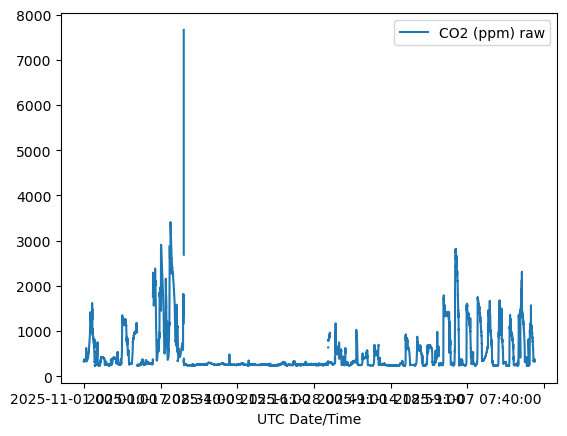

In [10]:
data = pd.read_csv('./data/processed_FULL.csv')

data.plot(x='UTC Date/Time', y='CO2 (ppm) raw')

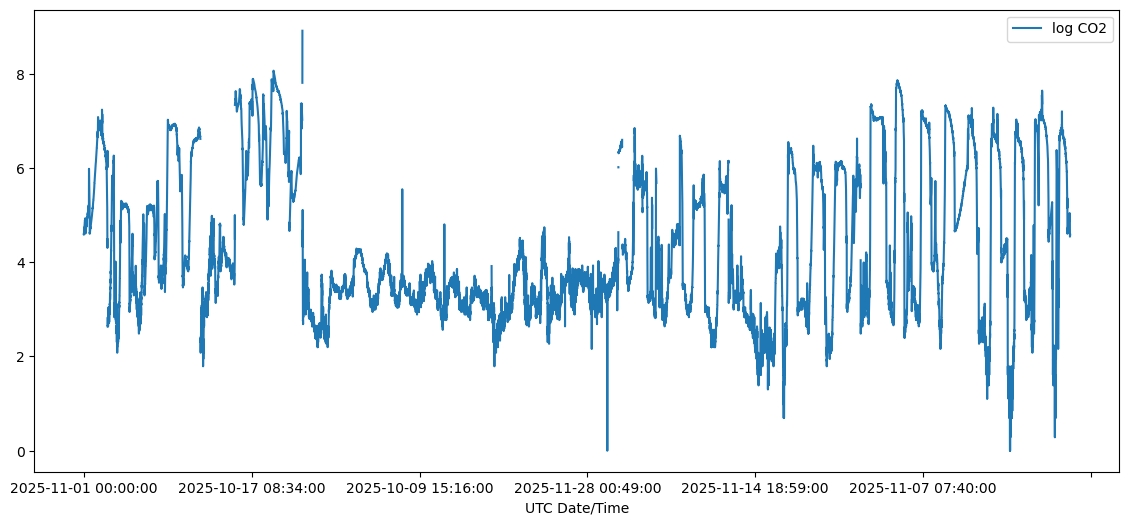

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (14, 6))

## approx steady state
C_min = data['CO2 (ppm) raw'].min()
data['CO2 translated'] = data['CO2 (ppm) raw'] - C_min + 1
data['log CO2'] = np.log(data['CO2 translated'])

data.plot(x = 'UTC Date/Time', y = 'log CO2', ax = ax)
ax.set_yscale('linear')

In [12]:
## approximation of second order derivative
data['log CO2'].rolling(window=3, center=True).mean()

0             NaN
1        4.586088
2        4.591702
3        4.598436
4        4.602929
           ...   
58756    4.567802
58757    4.571257
58758    4.574711
58759    4.578130
58760         NaN
Name: log CO2, Length: 58761, dtype: float64

In [13]:
ref_data = pd.read_csv('./data/lab_reference-CO2.csv')
ref_data['datetime_utc'].max()

'2025-10-12 22:55:00'

<Axes: xlabel='UTC Date/Time'>

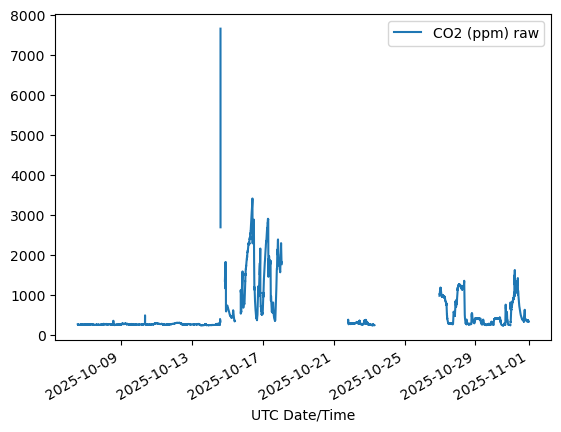

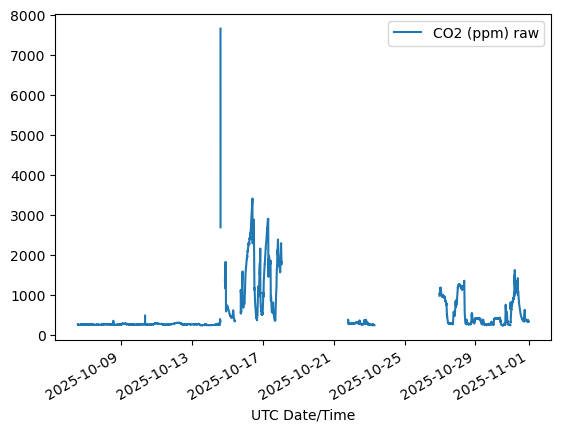

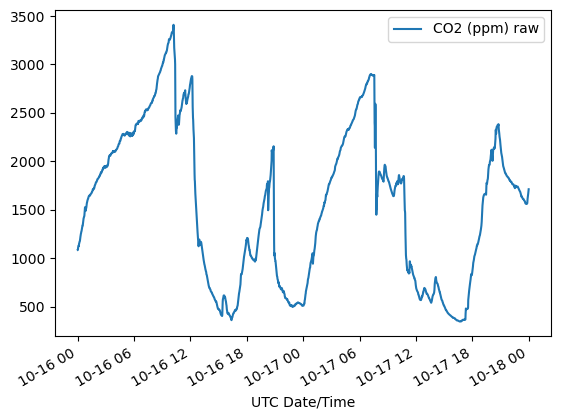

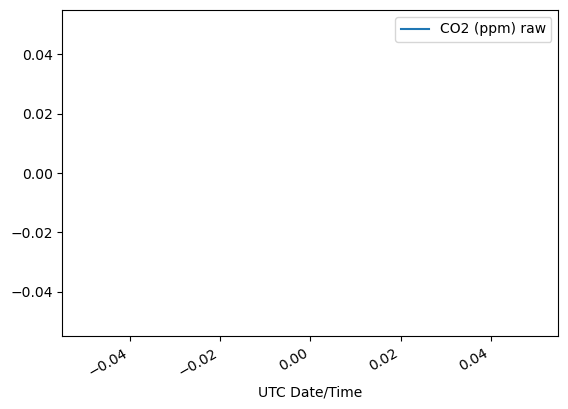

In [14]:
## old code

raw_data = pd.read_csv('./data/october_RAW.csv', parse_dates=['UTC Date/Time'])

raw_data.head()
## select useful columns
raw_data = raw_data[[
    'UTC Date/Time',
    'CO2 (ppm) raw'
]]

raw_data['UTC Date/Time'] = raw_data['UTC Date/Time'].dt.tz_localize(None)
raw_data.plot(x='UTC Date/Time', y='CO2 (ppm) raw')
## 1: snapping (rounding) to nearest minute

rounded_data = raw_data.copy()

rounded_data['UTC Date/Time'] = rounded_data['UTC Date/Time'].dt.round(freq='min')

## plot
rounded_data.plot(x='UTC Date/Time', y='CO2 (ppm) raw')
start_date = pd.Timestamp(2025, 10, 16)
end_date = start_date + pd.Timedelta(days=2) # pd.Timestamp(2025, 10, 15)

date_mask = (rounded_data['UTC Date/Time'] >= start_date) & (rounded_data['UTC Date/Time'] <= end_date)

cut_data = rounded_data[date_mask]
cut_data.plot(x='UTC Date/Time', y='CO2 (ppm) raw')
pairs = [
    (pd.Timestamp(2025, 10, 13, 9), pd.Timestamp(2025, 10, 13, 14))
]
start_date = pd.Timestamp(2025, 10, 15, 9)
end_date = pd.Timestamp(2025, 10, 13, 14)

date_mask = (rounded_data['UTC Date/Time'] >= start_date) & (rounded_data['UTC Date/Time'] <= end_date)

cut_data = rounded_data[date_mask]
cut_data.plot(x='UTC Date/Time', y='CO2 (ppm) raw')
